In [7]:
# !pip install -q unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/

In [8]:
from unsloth import FastLanguageModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [9]:
max_seq_length = 2048 # How much longer sequence we want to support in out Finetuned LLM
dtype = None  # None for auto detection. float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True  # use 4 bit quantization to reduce memory usage,  can be false

In [10]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = 'unsloth/Llama-3.2-3B-Instruct',
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit
)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.7k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


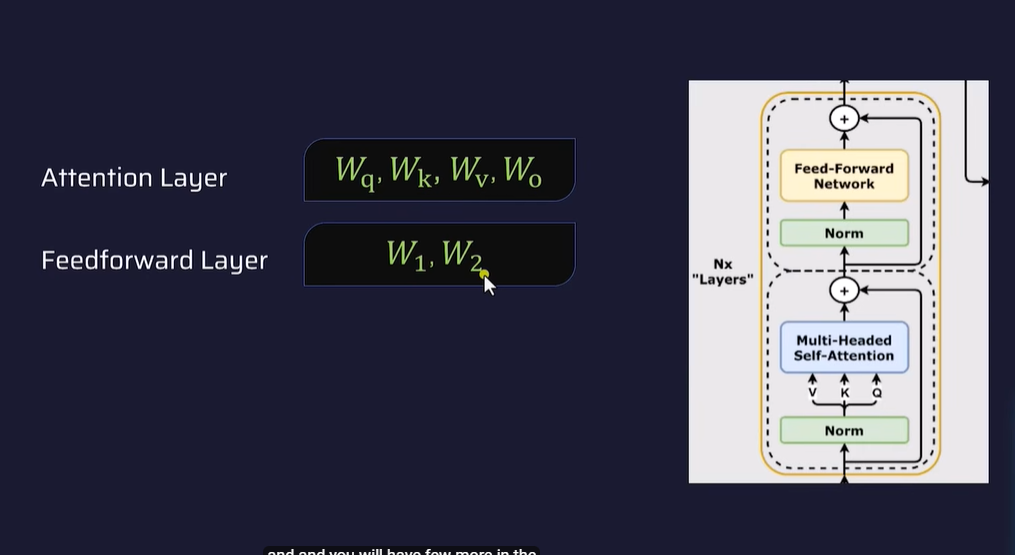

W = W0 + (alpha/rank) . (A x B)   this A x B is delta W

In [11]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",    # mention in above image, necessory to add all the adapters if we don't add k_proj for example it will not freeze the k layer and we will get different output, needed for delata W matrix like "Wq + delta W, Wk + delta W, Wv + delta W, Wo + delta W"
                      "gate_proj", "up_proj", "down_proj",],  # these are the metrices from fully connected layer
    lora_alpha = 16, # a higher alpha value assigns more weight to the LoRA activations
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


*   **r**: The rank of the low-rank matrices in LoRA; higher values can capture more information but increase memory usage.
*   **target_modules**: List of model components (e.g., "q_proj", "k_proj") where LoRA adapters are inserted for fine-tuning.
*   **lora_alpha**: Scaling factor for the LoRA updates; controls the impact of the adapters on the model's outputs.
*   **lora_dropout**: Dropout rate applied to LoRA layers during training to prevent overfitting.
*   **bias**: Specifies how biases are handled in LoRA layers; options include "none", "all", or "lora_only".
*   **use_gradient_checkpointing**: Enables gradient checkpointing to reduce memory usage during training; "unsloth" uses Unsloth's optimized version.
*   **random_state**: Seed for random number generators to ensure reproducibility of training results.
*   **use_rslora**: Boolean indicating whether to use Rank-Stabilized LoRA (rsLoRA) for potentially more stable training.
*   **loftq_config**: Configuration for Low-Rank Quantization (LoftQ); set to None to disable this feature.

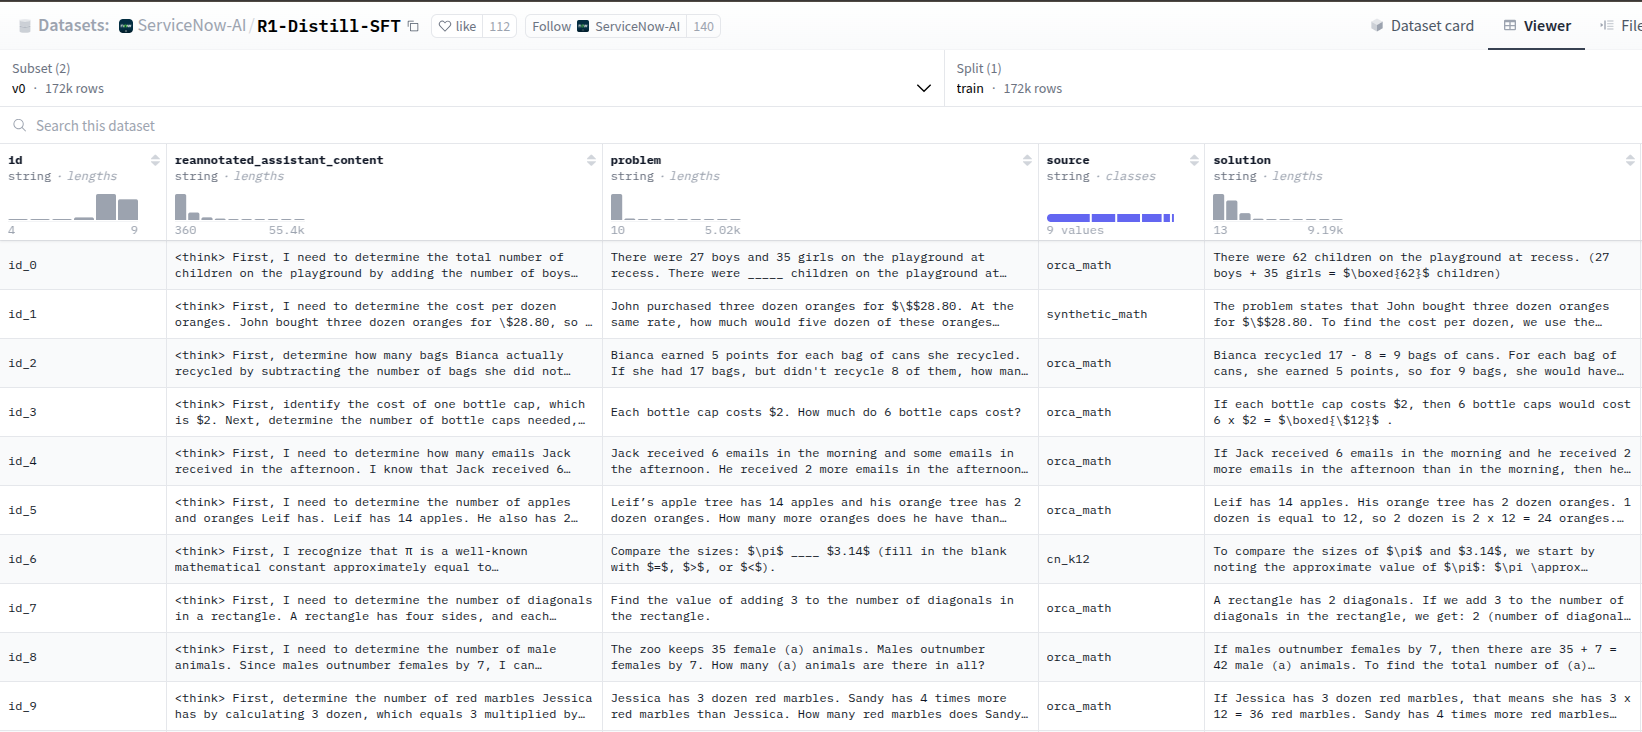

In [12]:
from datasets import load_dataset   #HuggingFace Library
dataset = load_dataset("ServiceNow-AI/R1-Distill-SFT",'v0', split="train")    # This dataset is for Maths reasoning problems

In [37]:
print(len(dataset))

171647


In [13]:
dataset[:2]

{'id': ['id_0', 'id_1'],
 'reannotated_assistant_content': ['<think>\nFirst, I need to determine the total number of children on the playground by adding the number of boys and girls.\n\nThere are 27 boys and 35 girls.\n\nAdding these together: 27 boys + 35 girls = 62 children.\n\nTherefore, the total number of children on the playground is 62.\n</think>\n\nTo find the total number of children on the playground, we simply add the number of boys and girls together.\n\n\\[\n\\text{Total children} = \\text{Number of boys} + \\text{Number of girls}\n\\]\n\nPlugging in the given values:\n\n\\[\n\\text{Total children} = 27 \\text{ boys} + 35 \\text{ girls} = 62 \\text{ children}\n\\]\n\n**Final Answer:**\n\n\\[\n\\boxed{62}\n\\]',
  '<think>\nFirst, I need to determine the cost per dozen oranges. John bought three dozen oranges for \\$28.80, so I can find the cost per dozen by dividing the total cost by the number of dozens.\n\nNext, with the cost per dozen known, I can calculate the cost fo

In [14]:
r1_prompt = """You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
{}
</problem>

{}            # Deepseek like thinking block
{}            # Solution
"""
EOS_TOKEN = tokenizer.eos_token

def formatting_prompts_func(examples):
  problems = examples["problem"]                          # Problem
  thoughts = examples["reannotated_assistant_content"]    # Deepseek like thinking block
  solutions = examples["solution"]                        # Solution
  texts = []

  for problem, thought, solution in zip(problems, thoughts, solutions):
    text = r1_prompt.format(problem, thought, solution)+EOS_TOKEN
    texts.append(text)

  return {"text": texts}  # return the text

dataset = dataset.map(formatting_prompts_func, batched = True,)  # map function Will go to every id in the dataset

Map:   0%|          | 0/171647 [00:00<?, ? examples/s]

**Trainer Setup:**
- `model` and `tokenizer`: These are the model and tokenizer objects that will be trained.

- `train_dataset`: The dataset used for training.

- `dataset_text_field`: Specifies the field in the dataset that contains the text data.

- `max_seq_length`: Maximum sequence length for the input data.

- `dataset_num_proc`: Number of processes to use for data loading.

- `packing`: If True, enables sequence packing (concatenates multiple examples into a single sequence to better utilize tokens).


**Training Arguments:**
- `per_device_train_batch_size`: Number of samples per batch for each device.

- `gradient_accumulation_steps`: Number of steps to accumulate gradients before updating model weights.

- `warmup_steps`: Number of steps for learning rate warmup.

- `max_steps`: Total number of training steps.

- `learning_rate`: Learning rate for the optimizer.

- `fp16` and `bf16`: Specifies whether to use 16-bit floating point precision or bfloat16, depending on hardware support.

- `logging_steps`: Frequency of logging training progress.

- `optim`: Optimizer type, here using an 8-bit version of AdamW.

- `weight_decay`: Regularization parameter for weight decay.

- `lr_scheduler_type`: Type of learning rate scheduler.

- `seed`: Random seed for reproducibility.

- `output_dir`: Directory where the training outputs will be saved.

- `report_to`: Integration for observability tools like "wandb", "tensorboard", etc.

In [15]:
from trl import SFTTrainer     # Transformer Reinforcement Library(HuggingFace)  we are importing a trainer SFTTrainer
from transformers import TrainingArguments, DataCollatorForSeq2Seq
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2, # Number of processors to use for processing the dataset
    packing = False, # Can make training 5x faster for short sequences.
    args = TrainingArguments(
        per_device_train_batch_size = 2, # The batch size per GPU/TPU core
        gradient_accumulation_steps = 4, # Number of steps to perform befor each gradient accumulation
        warmup_steps = 5, # Few updates with low learning rate before actual training
        max_steps = 60, # Specifies the total number of training steps (batches) to run.
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit", # Optimizer
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        save_strategy = "no",   # disables checkpoint saving mid-training
        output_dir = "outputs",
        report_to = "none", # Use this for WandB etc for observability
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/171647 [00:00<?, ? examples/s]

In [16]:
trainer_stats = trainer.train()  # loss should be below 0.5, and it more depend on the usecase

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 171,647 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,1.033432
2,0.944234
3,1.043563
4,0.969980
5,0.813074
6,0.879298
7,0.792036
8,0.771775
9,0.821203
10,0.739192


In [17]:
from unsloth.chat_templates import get_chat_template
sys_prompt = """You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
{}
</problem>
"""
message = sys_prompt.format("How many 'r's are present in 'strawberry'?")
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "llama-3.1",
)
FastLanguageModel.for_inference(model) # Enable native 2x faster inference

messages = [
    {"role": "user", "content": message},
]
inputs = tokenizer.apply_chat_template(
    messages,
    tokenize = True,
    add_generation_prompt = True, # Must add for generation
    return_tensors = "pt",
).to("cuda")

outputs = model.generate(input_ids = inputs, max_new_tokens = 1024, use_cache = True,
                         temperature = 1.5, min_p = 0.1)
response = tokenizer.batch_decode(outputs)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=1024) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_att

In [18]:
print(response[0])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 July 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

You are a reflective assistant engaging in thorough, iterative reasoning, mimicking human stream-of-consciousness thinking. Your approach emphasizes exploration, self-doubt, and continuous refinement before coming up with an answer.
<problem>
How many 'r's are present in'strawberry'?
</problem>
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Alright, let me figure out how many 'r's are in the word'strawberry'. Okay, so I remember that 'r' is the seventh letter of the alphabet, but is that correct? Let me just check again to make sure. In the standard English alphabet, 'r' is indeed the seventh letter, so that's probably correct.

Okay, now, looking at'strawberry'. It's a seven-letter word. I need to count the number of 'r's in it. Let's break it down:

- S: That's's'. No 'r's here.
- T: That's 't'. Stil

In [19]:
model.save_pretrained_merged(          #save whole model
    "Math_solver-001-3B-full",   # folder name
    tokenizer,
    save_method = "merged_16bit"
)

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in Math_solver-001-3B-full/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [02:13<00:00, 66.55s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:13<00:00, 66.75s/it]


Unsloth: Merge process complete. Saved to `/content/Math_solver-001-3B-full`


In [38]:
import shutil

shutil.copytree(
    "/content/Math_solver-001-3B-full",
    "/content/drive/MyDrive/LLM/Math_solver-001-3B-full"
)

print("✅ Model copied to Google Drive!")

✅ Model copied to Google Drive!


In [28]:
from unsloth import FastLanguageModel

# Load your saved model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = r"/content/Math_solver-001-3B-full",  # path to your folder
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

The tokenizer you are loading from '/content/Math_solver-001-3B-full' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
The tokenizer you are loading from '/content/Math_solver-001-3B-full' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Unsloth: Will load /content/Math_solver-001-3B-full as a legacy tokenizer.


In [36]:
from unsloth.chat_templates import get_chat_template

# Enable inference mode
FastLanguageModel.for_inference(model)

# Run inference
tokenizer = get_chat_template(tokenizer, chat_template="llama-3")

inputs = tokenizer(
    [sys_prompt.format("Count number of s in beans", "", "")],
    return_tensors = "pt"
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens = 256,
    eos_token_id = tokenizer.eos_token_id,   # ← stops at end of response
    pad_token_id = tokenizer.eos_token_id,   # ← add this too
    temperature = 0.7,
    do_sample = True,
)

# Decode only NEW tokens (not the input prompt)
response = tokenizer.decode(
    outputs[0][inputs.input_ids.shape[1]:],  # ← skip input tokens
    skip_special_tokens = True
)
print(response)

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


<think>
First, I need to determine the number of letters in the word "beans." 

The word "beans" has 5 letters: B-E-A-N-S.

Next, I have to count how many times the letter "S" appears in the word "beans." 

The letter "S" appears only once in the word "beans."

So, the number of S in beans is 1.
</think>

To find the number of S in the word "beans," follow these steps:

1. **Count the total number of letters in "beans":**
   - "beans" has 5 letters: B-E-A-N-S.

2. **Identify the number of S's in "beans":**
   - There is only 1 S in the word "beans."

**Final Answer:**
\[
\boxed{1}
\]            # Deepseek like thinking block
To find the number of S in the word "beans," follow these steps:

1. **Count the total number of letters in "beans":**
   - "beans" has 5 letters: B-E-A-N-S.

2. **Identify the number of S's in "beans":**
   - There is only 1 S in the word
